In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Data Preprocessing

**Test Image Processing**

In [3]:
training_set=tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 70295 files belonging to 38 classes.


**Validation Image Processing**

In [4]:
validation_set=tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [5]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [6]:
for x,y in training_set:
    print(x, x.shape)
    print(y, y.shape)
    break

tf.Tensor(
[[[[155.25 151.25 141.25]
   [152.   148.   138.  ]
   [143.75 139.75 130.75]
   ...
   [186.   182.   179.  ]
   [187.5  183.5  180.5 ]
   [175.5  171.5  168.5 ]]

  [[146.5  143.75 125.25]
   [153.   149.75 135.  ]
   [149.5  145.25 136.  ]
   ...
   [173.5  169.5  166.5 ]
   [178.25 174.25 171.25]
   [174.75 170.75 167.75]]

  [[149.5  146.25 130.  ]
   [150.5  147.5  132.  ]
   [148.   144.5  130.75]
   ...
   [168.   164.   161.  ]
   [169.75 165.75 162.75]
   [168.25 164.25 161.25]]

  ...

  [[ 93.75  88.75  82.75]
   [ 91.25  86.25  80.25]
   [ 91.75  86.75  80.75]
   ...
   [ 97.5   94.5   89.5 ]
   [ 95.75  92.75  87.75]
   [ 93.5   90.5   85.5 ]]

  [[ 93.75  88.75  82.75]
   [ 91.    86.    80.  ]
   [ 90.5   85.5   79.5 ]
   ...
   [ 98.25  95.25  90.25]
   [ 96.75  93.75  88.75]
   [ 94.5   91.5   86.5 ]]

  [[ 92.5   87.5   81.5 ]
   [ 92.5   87.5   81.5 ]
   [ 91.25  86.25  80.25]
   ...
   [ 99.    96.    91.  ]
   [ 97.5   94.5   89.5 ]
   [ 95.    92.    8

# Building Model

In [7]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.models import Sequential
model=Sequential()

**Building Concolutional Layer**

In [8]:
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=[128,128,3]))
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [9]:
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu', input_shape=[128,128,3]))
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [10]:
model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu', input_shape=[128,128,3]))
model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [11]:
model.add(Conv2D(filters=256, kernel_size=3, padding='same', activation='relu', input_shape=[128,128,3]))
model.add(Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [12]:
model.add(Flatten())

In [13]:
model.add(Dense(units=1024, activation='relu'))

**Output Layer**

In [14]:
model.add(Dense(units=38, activation='softmax'))

# Compiling Model

In [15]:
from keras.metrics import CategoricalAccuracy
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=[CategoricalAccuracy()])

In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 64, 64, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 64)       0         
 2D)                                                    

# Training Model

In [17]:
training_history=model.fit(x=training_set, validation_data=validation_set, epochs=10)

Epoch 1/10
2197/2197 [==============================] - 210s 91ms/step - loss: 1.1097 - categorical_accuracy: 0.6774 - val_loss: 0.4428 - val_categorical_accuracy: 0.8558
Epoch 2/10
2197/2197 [==============================] - 196s 89ms/step - loss: 0.3214 - categorical_accuracy: 0.8949 - val_loss: 0.2671 - val_categorical_accuracy: 0.9149
Epoch 3/10
2197/2197 [==============================] - 196s 89ms/step - loss: 0.2267 - categorical_accuracy: 0.9250 - val_loss: 0.2857 - val_categorical_accuracy: 0.9099
Epoch 4/10
2197/2197 [==============================] - 197s 90ms/step - loss: 0.1767 - categorical_accuracy: 0.9413 - val_loss: 0.3234 - val_categorical_accuracy: 0.8990
Epoch 5/10
2197/2197 [==============================] - 197s 90ms/step - loss: 0.1603 - categorical_accuracy: 0.9476 - val_loss: 0.4376 - val_categorical_accuracy: 0.8869
Epoch 6/10
2197/2197 [==============================] - 197s 89ms/step - loss: 0.1442 - categorical_accuracy: 0.9537 - val_loss: 0.4378 - val_cat

# Model Evaluation

In [18]:
train_loss, train_acc=model.evaluate(training_set)

2197/2197 [==============================] - 102s 46ms/step - loss: 0.1231 - categorical_accuracy: 0.9607


In [19]:
print(train_loss, train_acc)

0.12310819327831268 0.960665762424469


In [20]:
val_loss, val_acc=model.evaluate(validation_set)

550/550 [==============================] - 12s 22ms/step - loss: 0.3442 - categorical_accuracy: 0.9108


In [21]:
print(val_loss, val_acc)

0.3442133665084839 0.910767138004303


In [40]:
model.save("trained_model.h5")

In [23]:
training_history.history

{'loss': [1.109719157218933,
  0.32138705253601074,
  0.2267242819070816,
  0.17670245468616486,
  0.1602921485900879,
  0.1441943198442459,
  0.12904846668243408,
  0.1276828795671463,
  0.1216047927737236,
  0.13320738077163696],
 'categorical_accuracy': [0.6774023771286011,
  0.894928514957428,
  0.9250018000602722,
  0.9412760734558105,
  0.9476349949836731,
  0.9536666870117188,
  0.9581762552261353,
  0.9591578245162964,
  0.9606800079345703,
  0.9587594866752625],
 'val_loss': [0.4427906572818756,
  0.26708880066871643,
  0.28568312525749207,
  0.32336223125457764,
  0.4375888705253601,
  0.43780121207237244,
  0.31489986181259155,
  0.28684014081954956,
  0.36139383912086487,
  0.3442132771015167],
 'val_categorical_accuracy': [0.855793297290802,
  0.9149214625358582,
  0.9098566174507141,
  0.8989869952201843,
  0.886865496635437,
  0.8753129839897156,
  0.9179376363754272,
  0.9183928966522217,
  0.9030275344848633,
  0.910767138004303]}

In [24]:
import json
with open("training_history.json", 'w') as f:
    json.dump(training_history.history, f)

In [25]:
training_history.history['val_categorical_accuracy']

[0.855793297290802,
 0.9149214625358582,
 0.9098566174507141,
 0.8989869952201843,
 0.886865496635437,
 0.8753129839897156,
 0.9179376363754272,
 0.9183928966522217,
 0.9030275344848633,
 0.910767138004303]

# Accuracy Visualization

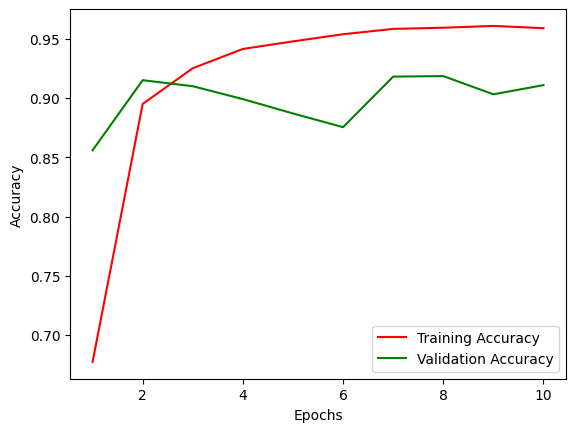

In [26]:
epochs = [i for i in range(1, 11)]
plt.plot(epochs, training_history.history['categorical_accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_categorical_accuracy'], color='green', label='Validation Accuracy')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()


# Model Evaluation Matrics

In [27]:
class_name=validation_set.class_names

In [28]:
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [29]:
test_set=tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [30]:
y_pred=model.predict(test_set)
y_pred

550/550 [==============================] - 12s 22ms/step


array([[9.99984622e-01, 1.61101052e-08, 5.29288391e-10, ...,
        1.48110246e-17, 6.16831944e-13, 2.88133609e-15],
       [1.00000000e+00, 6.75138410e-16, 2.80031316e-16, ...,
        4.73837043e-25, 5.42300944e-15, 4.74956404e-21],
       [9.99241352e-01, 9.64257785e-10, 4.85734475e-08, ...,
        1.28845011e-17, 7.73628801e-14, 4.44095698e-11],
       ...,
       [8.68853767e-10, 9.35052525e-20, 7.98863056e-08, ...,
        3.52526319e-09, 8.76399927e-18, 9.99999523e-01],
       [5.23042543e-09, 4.86790827e-19, 1.03725810e-08, ...,
        1.47984679e-07, 1.10422374e-14, 9.99998093e-01],
       [3.26379786e-14, 2.66749594e-13, 7.00199274e-11, ...,
        4.00769693e-08, 5.94589665e-06, 9.89046514e-01]], dtype=float32)

In [31]:
y_pred.shape

(17572, 38)

In [32]:
predicted_categories=tf.argmax(y_pred, axis=1)

In [33]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [34]:
true_categories=tf.concat([y for x,y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [35]:
y_true=tf.argmax(true_categories, axis=1)
y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [36]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, predicted_categories, target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.83      0.94      0.88       504
                                 Apple___Black_rot       0.97      0.98      0.97       497
                          Apple___Cedar_apple_rust       0.87      0.95      0.91       440
                                   Apple___healthy       0.85      0.91      0.88       502
                               Blueberry___healthy       0.88      0.95      0.92       454
          Cherry_(including_sour)___Powdery_mildew       0.98      0.90      0.94       421
                 Cherry_(including_sour)___healthy       0.98      0.95      0.96       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.85      0.92      0.88       410
                       Corn_(maize)___Common_rust_       0.98      0.99      0.98       477
               Corn_(maize)___Northern_Leaf_Blight       0.87      0.91      0.

In [37]:
cm=confusion_matrix(y_true, predicted_categories)
cm

array([[473,   2,   3, ...,   0,   1,   1],
       [  2, 485,   1, ...,   0,   0,   0],
       [  0,   2, 416, ...,   2,   0,   2],
       ...,
       [  0,   0,   1, ..., 465,   2,   2],
       [  1,   0,   0, ...,   0, 431,   1],
       [  3,   0,   0, ...,   0,   0, 456]], dtype=int64)

In [38]:
cm.shape

(38, 38)

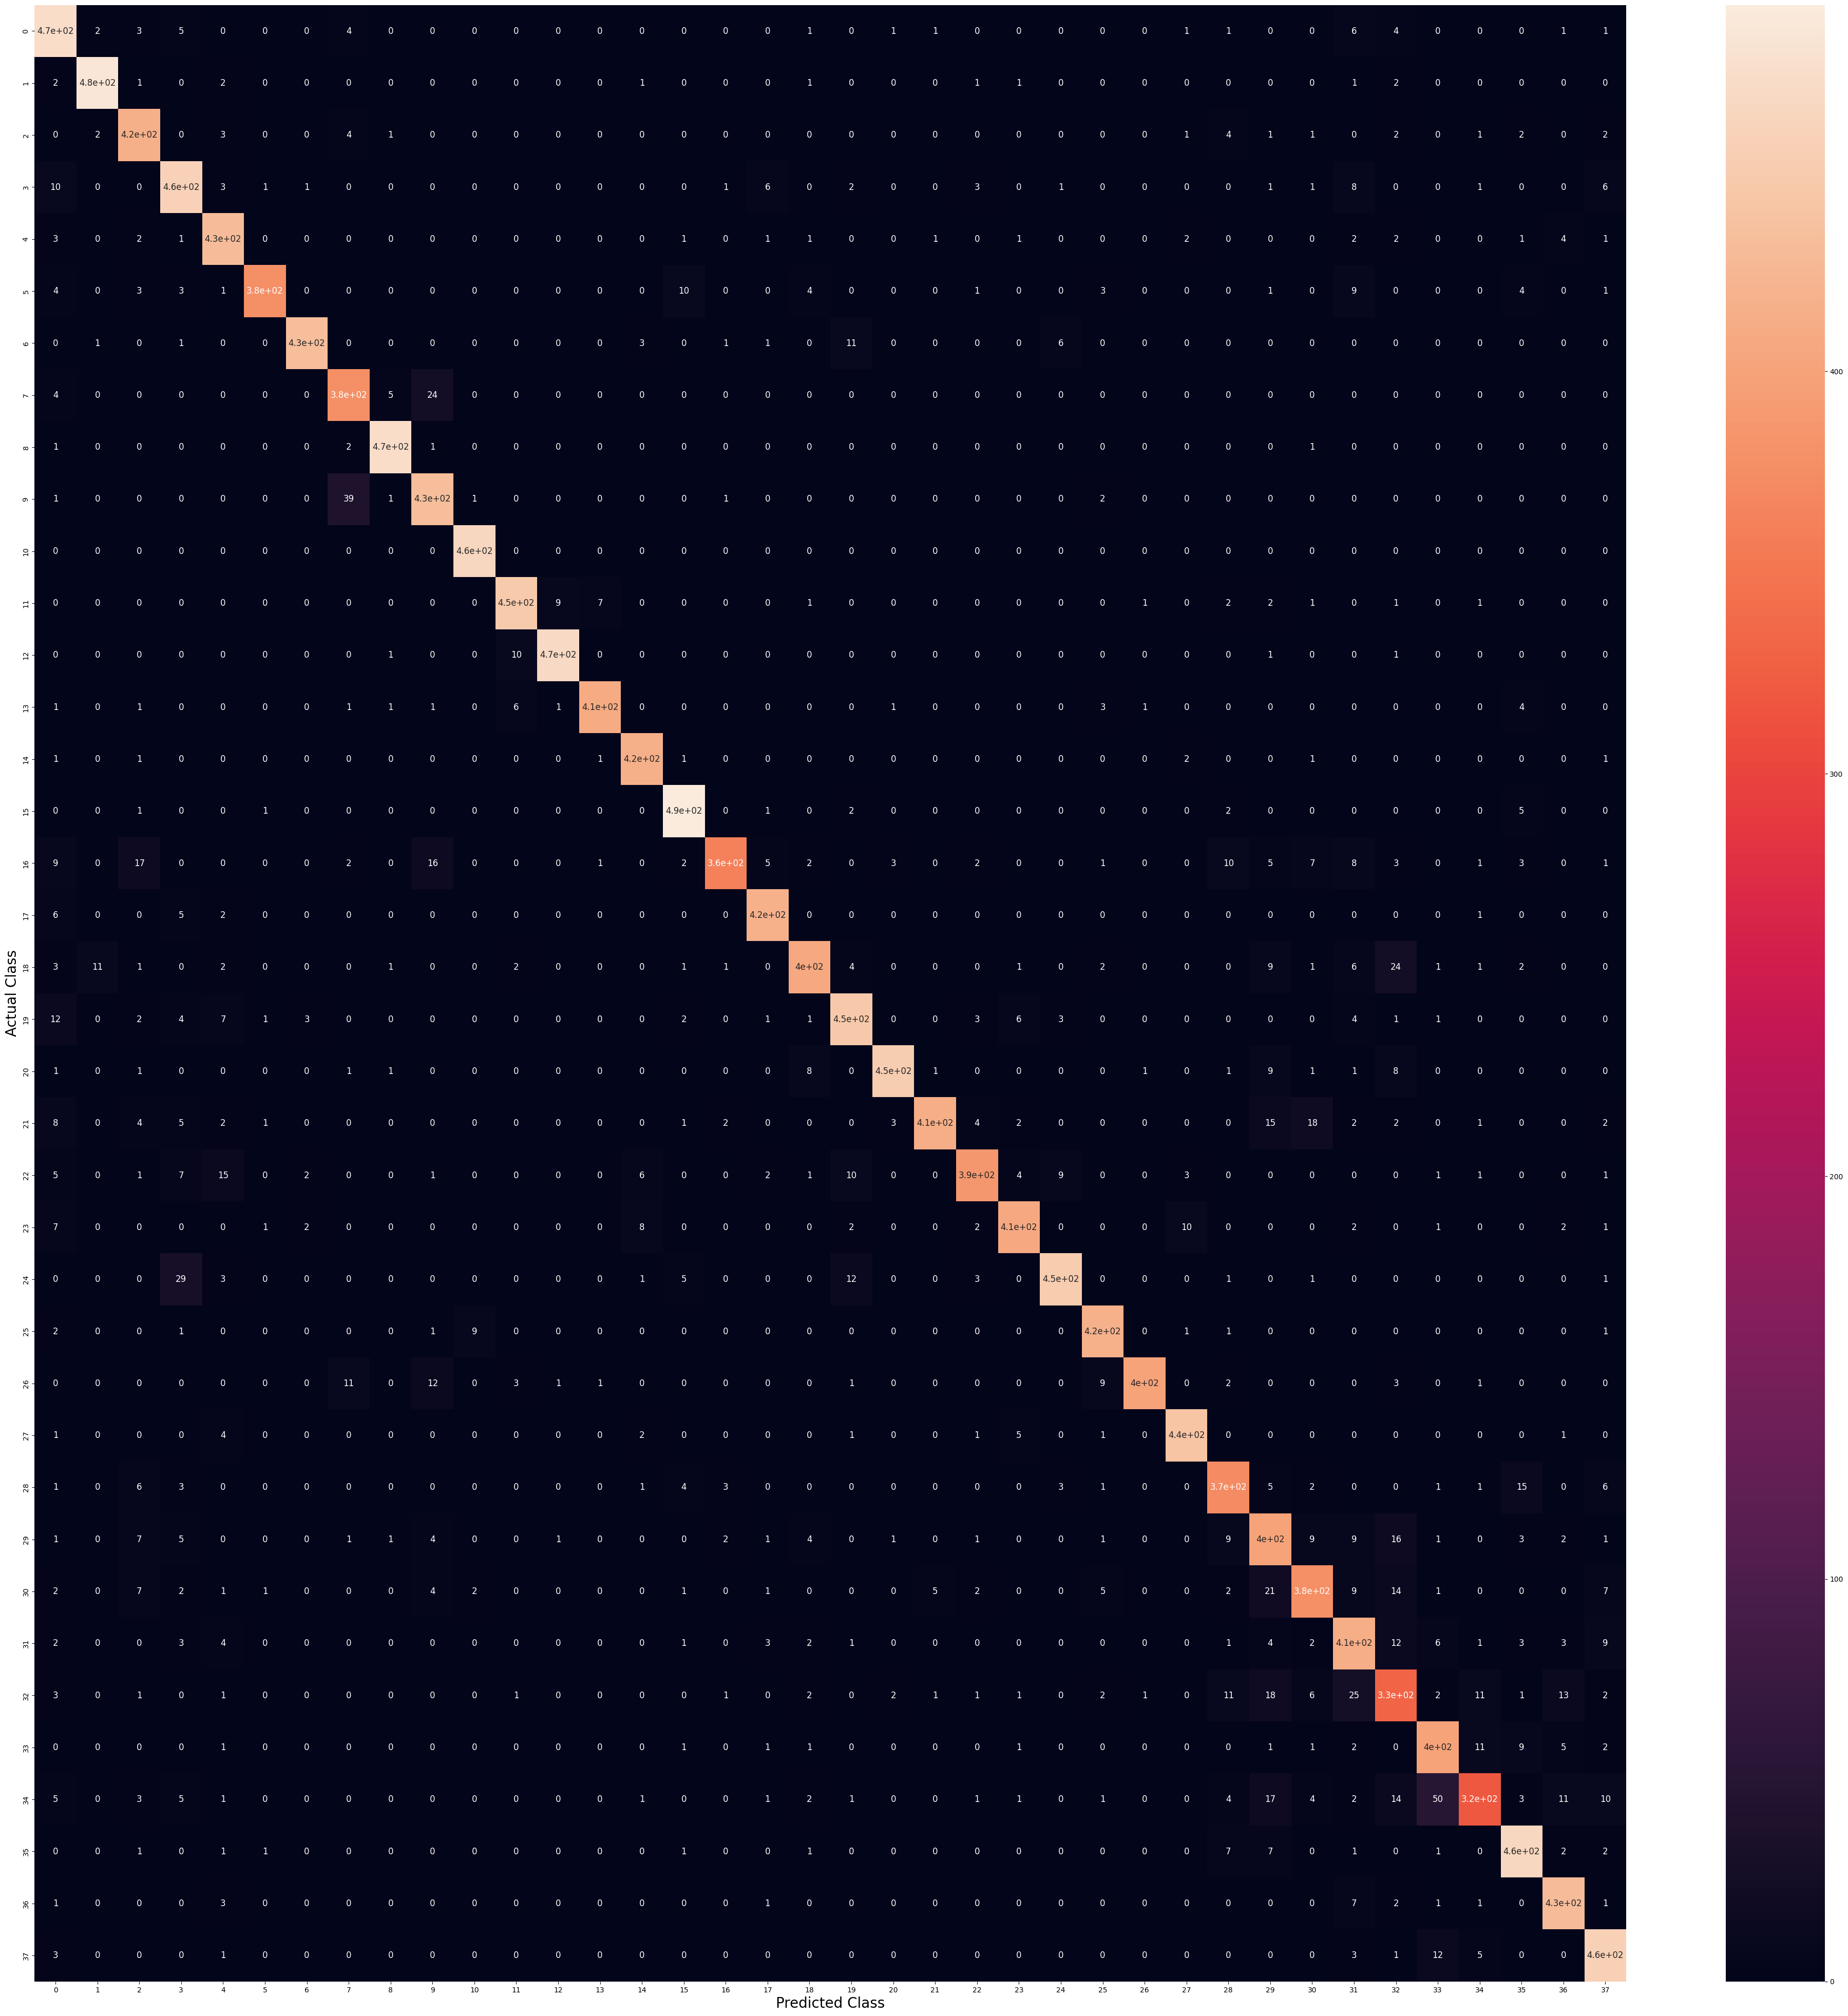

In [39]:
import seaborn as sns
plt.figure(figsize=(50,50))
sns.heatmap(cm, annot=True, annot_kws={"size":12})
plt.xlabel("Predicted Class", fontsize=20)
plt.ylabel("Actual Class", fontsize=20)
plt.show()